# fNL fits & posteriors for PNG-UNIT-XL (GCcomb)

Fits the PNG-UNIT-XL `mesh2_spectrum` (FKP/OQE, **GCcomb**) for each fNL value
(`fnlm20`, `fnl0`, `fnl20`) using the **data window** (optimal OQE weights)
and the **HOLI mock covariance**, with the same `tools.py` / `desilike` machinery as
`validation_mocks.ipynb`.

For each fNL we run the same test on four data combinations:
`LRGxLRG`, `QSOxQSO`, `LRGxLRG+QSOxQSO`, and `LRGxLRG+QSOxQSO+LRGxQSO` (the last is the
fiducial). For each: **(3)** profiler best-fits and **(4)** MCMC posteriors of the free
parameters.

Run in the cosmodesi-main-dev env from this directory. If you haven't set up the cosmodesi-main-dev jupyter kernel, [see these instructions](https://github.com/cosmodesi/desi-clustering/tree/main#how-to-install-developement-mode-jupyter-kernel).

In [1]:
import logging, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG-UNIT-XL')
os.environ['OMPI_MCA_btl'] = 'self,tcp'
logging.getLogger('jax._src.xla_bridge').setLevel(logging.ERROR)
logging.getLogger('jax._src.distributed').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
import lsstypes
from clustering_statistics import tools as cs_tools, setup_logging
from clustering_statistics.tools import get_stats_fn

from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

from tools import (read_data, rebin_data, get_observable_and_likelihood,
                   build_total_likelihood, run_profiler, run_mcmc,
                   get_getdist_plotter, plot_triangle)

## Configuration

In [3]:
# HOLI auxiliary products (data window with RIC, mock covariance) -- Cai's shared tree:
root      = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
data_dir  = root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

# PNG-UNIT-XL measurements (written by desipipe_pngunit-xl_mocks.py):
PNG_STATS_DIR = Path(os.environ['SCRATCH']) / 'measurements'
PNG_PROJECT   = 'local_png/base'
PNG_VERSION   = 'pngunit-xl'
PNG_WEIGHT    = 'default-fkp-oqe'

region    = 'GCcomb'
fnls      = ['fnlm20', 'fnl0', 'fnl20']
fnl_truth = {'fnlm20': -20., 'fnl0': 0., 'fnl20': 20.}
fnl_color = {'fnlm20': 'C0', 'fnl0': 'C1', 'fnl20': 'C2'}

WINDOW_EXTRA = 'RIC' # data window with RIC (PNGUNIT-XL randoms are shuffled in a similar way to the data)

# Fit k-range (h/Mpc), applied to BOTH multipoles (ell = 0 and ell = 2):
KMAX        = 8e-2                                               # upper bound, same for every measurement
kmin_tracer = {'LRGxLRG': 5e-3, 'QSOxQSO': 3e-3, 'LRGxQSO': 5e-3}  # lower bound, per measurement
kmin_load   = 1e-3                                              # kmin used only when loading/rebinning

# ~ Table 3 of Adame ++
P_VALUES = {
    'fnlm20': {'LRG': 0.8, 'QSO': 0.83},
    'fnl0':   {'LRG': 0.8, 'QSO': 0.83},
    'fnl20':  {'LRG': 1.13, 'QSO': 1.55},
}

# data combinations to test (last = fiducial):
ORDERS = [['LRGxLRG'], ['QSOxQSO'], ['LRGxLRG', 'QSOxQSO'],
          ['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
labels = {'LRGxLRG': 'LRG', 'QSOxQSO': 'QSO', 'LRGxLRG-QSOxQSO': 'LRG+QSO',
          'LRGxLRG-QSOxQSO-LRGxQSO': 'LRGxQSO'}

# tracer-key -> (HOLI/data read token, PNG measurement tracer, fiducial key)
HOLI_TRACER = {'LRGxLRG': 'LRG', 'QSOxQSO': 'QSO', 'LRGxQSO': 'LRGxQSO'}
PNG_TRACER  = {'LRGxLRG': 'LRG', 'QSOxQSO': 'QSO', 'LRGxQSO': ('LRG', 'QSO')}
FID_KEY     = {'LRGxLRG': 'LRG', 'QSOxQSO': 'QSO', 'LRGxQSO': 'LRGxQSO'}
TRACER_KEYS = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO']


def propose_fiducial(kmin=1e-3, kmax=KMAX, region='GCcomb'):
    """Same fiducial scales/regions/weights as validation_mocks.ipynb."""
    def base(zr):
        return {'weight_type': 'default-fkp-oqe', 'zrange': zr, 'region': region,
                'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    return {'LRG': base((0.4, 1.1)), 'QSO': base((0.8, 3.5)), 'LRGxQSO': base((0.8, 1.1))}

print('PNG dir :', PNG_STATS_DIR, '(exists:', PNG_STATS_DIR.exists(), ')')
print('HOLI dir:', Path(mocks_dir).exists())

PNG dir : /pscratch/sd/n/nsailer/measurements (exists: True )
HOLI dir: True


## Load: HOLI window (RIC) + mock covariance, and PNG-UNIT-XL data (GCcomb)

In [4]:
def load_holi_aux(tracer_key, region='GCcomb', window_extra=WINDOW_EXTRA):
    """HOLI data window (with RIC) + HOLI mock list (used as covariance), rebinned."""
    fid = propose_fiducial(kmin=kmin_load, region=region)[FID_KEY[tracer_key]]
    pk, win, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir,
                                   tracer=HOLI_TRACER[tracer_key], window_extra=window_extra,
                                   weight_type_mocks=PNG_WEIGHT, **fid)
    pk, win, cov, mock = rebin_data(pk, win, cov, mock, tracer=HOLI_TRACER[tracer_key], **fid)
    zeff = {0: win.observable.get(0).attrs['zeff']}
    try:
        zeff[2] = win.observable.get(2).attrs['zeff']
    except KeyError:
        pass
    return win, mock, zeff


def load_png(tracer_key, fnl, region='GCcomb'):
    """PNG-UNIT-XL pk for one fNL, on the canonical rebinned grid."""
    tr = PNG_TRACER[tracer_key]
    zr = cs_tools.propose_fiducial('zranges', tr, analysis='local_png')[0]
    # v2 layout: fNL is a sub-directory of the version ('pngunit-xl/<fnl>'), no `extra` tag.
    fn = get_stats_fn(kind='mesh2_spectrum', stats_dir=PNG_STATS_DIR, project=PNG_PROJECT,
                      version=f'{PNG_VERSION}/{fnl}', tracer=tr, region=region, zrange=zr,
                      weight=PNG_WEIGHT)
    fid = propose_fiducial(kmin=kmin_load, region=region)[FID_KEY[tracer_key]]
    pk, _, _, _ = rebin_data(lsstypes.read(fn), None, None, None, tracer=tracer_key, **fid)
    return pk


window, mocks, zeffs, png = {}, {}, {}, {}
for tk in TRACER_KEYS:
    window[tk], mocks[tk], zeffs[tk] = load_holi_aux(tk, region)
    png[tk] = {fnl: load_png(tk, fnl, region) for fnl in fnls}
    logger.info(f'loaded {tk}: nmocks={len(mocks[tk])}, fNL={list(png[tk])}')

print('Fit k-range per measurement (multipoles ell = 0, 2):')
for tk in TRACER_KEYS:
    print(f'  {tk:8s}  kmin = {kmin_tracer[tk]:.0e}  kmax = {KMAX:.0e}  h/Mpc')

[000000.14] [0/1] 06-10 13:42  PNG fitting tools         INFO     Reading the window with window_extra='RIC'
[000052.95] [0/1] 06-10 13:43  FIT PNG-UNIT-XL           INFO     loaded LRGxLRG: nmocks=1000, fNL=['fnlm20', 'fnl0', 'fnl20']
[000053.00] [0/1] 06-10 13:43  PNG fitting tools         INFO     Reading the window with window_extra='RIC'
[000087.92] [0/1] 06-10 13:43  FIT PNG-UNIT-XL           INFO     loaded QSOxQSO: nmocks=1000, fNL=['fnlm20', 'fnl0', 'fnl20']
[000087.97] [0/1] 06-10 13:43  PNG fitting tools         INFO     Reading the window with window_extra='RIC'
[000124.76] [0/1] 06-10 13:44  FIT PNG-UNIT-XL           INFO     loaded LRGxQSO: nmocks=1000, fNL=['fnlm20', 'fnl0', 'fnl20']
Fit k-range per measurement (multipoles ell = 0, 2):
  LRGxLRG   kmin = 5e-03  kmax = 8e-02  h/Mpc
  QSOxQSO   kmin = 3e-03  kmax = 8e-02  h/Mpc
  LRGxQSO   kmin = 5e-03  kmax = 8e-02  h/Mpc


## PNG-UNIT-XL measurements vs HOLI mock mean

[000124.78] [0/1] 06-10 13:44  PNG fitting tools         INFO     Reading the window with window_extra='RIC'
[000124.84] [0/1] 06-10 13:44  PNG fitting tools         INFO     Reading the window with window_extra='RIC'
[000124.89] [0/1] 06-10 13:44  PNG fitting tools         INFO     Reading the window with window_extra='RIC'


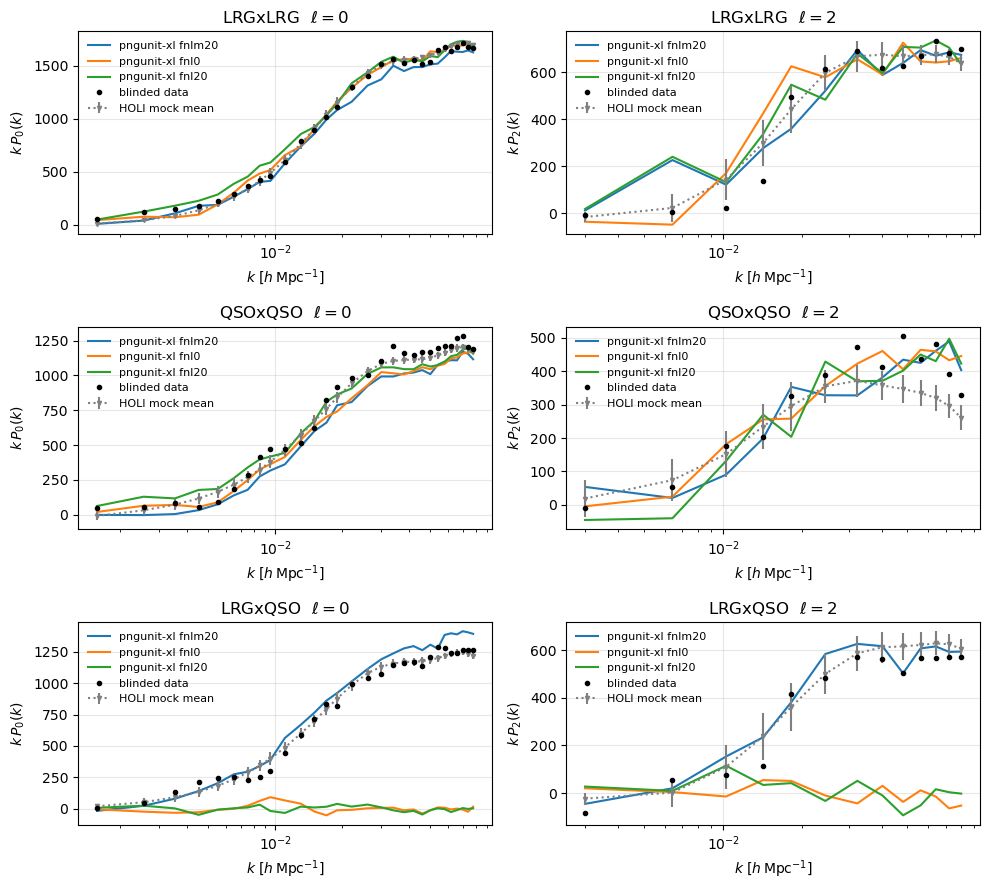

In [5]:
# PNG-UNIT-XL measurements vs HOLI mock mean AND blinded data (GCcomb), per tracer and multipole.
data_pk = {}
for tk in TRACER_KEYS:
    fid = propose_fiducial(kmin=kmin_load, region=region)[FID_KEY[tk]]
    pk, *_ = read_data(data_dir=data_dir, mocks_dir=None, tracer=HOLI_TRACER[tk],
                       window_extra=WINDOW_EXTRA, weight_type_mocks=PNG_WEIGHT, **fid)
    data_pk[tk], *_ = rebin_data(pk, None, None, None, tracer=HOLI_TRACER[tk], **fid)

_ells = [0, 2]
fig, axes = plt.subplots(len(TRACER_KEYS), len(_ells),
                         figsize=(10, 3.0 * len(TRACER_KEYS)), squeeze=False)
for r, tk in enumerate(TRACER_KEYS):
    mean = lsstypes.mean(mocks[tk])                           # HOLI mock mean
    std  = np.sqrt(np.diag(lsstypes.cov(mocks[tk]).value()))  # HOLI mock std (error band)
    n0 = mocks[tk][0].get(0).k.size
    for c, ell in enumerate(_ells):
        ax = axes[r, c]
        for fnl in fnls:                                      # the three PNG-UNIT-XL measurements
            m = png[tk][fnl].get(ell)
            ax.plot(m.k, m.k * m.value(), color=fnl_color[fnl], lw=1.5,
                    label=f'pngunit-xl {fnl}')
        sl = slice(0, n0) if ell == 0 else slice(n0, None)
        h = mean.get(ell)                                     # HOLI mock mean +/- std
        ax.errorbar(h.k, h.k * h.value(), yerr=h.k * std[sl], color='gray',
                    marker='v', ms=3, ls=':', zorder=9, label='HOLI mock mean')
        d = data_pk[tk].get(ell)                              # blinded data
        ax.plot(d.k, d.k * d.value(), color='k', marker='o', ms=3, ls='none',
                zorder=10, label='blinded data')
        ax.set_xscale('log'); ax.grid(alpha=0.3)
        ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
        ax.set_ylabel(rf'$k\,P_{{{ell}}}(k)$')
        ax.set_title(f'{tk}  $\\ell={ell}$')
        ax.legend(fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

## (3) Profiler fits for fNL = -20, 0, +20

Each combination is fit with the RIC window and the HOLI mock covariance, sharing a single
`fnl_loc` across tracers (`build_total_likelihood`). Each measurement is fit over k in [`kmin_tracer`, `KMAX`] for both multipoles
(ell = 0, 2); the per-measurement kmin/kmax are printed above.

In [6]:
def fit_combo(order, fnl):
    """Build the likelihood for a data combination and one fNL value."""
    pp, obs, mm = {}, {}, {}
    for tt in order:
        kmn = kmin_tracer[tt]
        pp[tt] = png[tt][fnl].select(k=(kmn, KMAX))
        ww = window[tt].at.observable.match(pp[tt])
        mm[tt] = [m.select(k=(kmn, KMAX)) for m in mocks[tt]]
        obs[tt], lik = get_observable_and_likelihood(pp[tt], ww, mm[tt], tt, zeffs,
                                                     p=P_VALUES[fnl], engine='camb',
                                                     fix_fnl=False, nickname=tt)
    if len(order) > 1:
        lik = build_total_likelihood(order, pp, obs, mm, zeffs,
                                     propose_fiducial(kmin=kmin_load, region=region))
    return obs, lik


profilers = {}
for fnl in fnls:
    for order in ORDERS:
        tag = '-'.join(order)
        _, lik = fit_combo(order, fnl)
        profilers[(tag, fnl)] = run_profiler(lik)
        logger.info(f'profiled {tag} {fnl}')

[000128.98] [0/1] 06-10 13:44  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000129.47] [0/1] 06-10 13:44  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[000129.59] [0/1] 06-10 13:44  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000130.54] [0/1] 06-10 13:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 37 points built from 1000 observations.
[000130.54] [0/1] 06-10 13:44  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9620.
[000137.35] [0/1] 06-10 13:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 37 points built from 1000 observations, varying 4 parameters.
[000137.35] [0/1] 06-10 13:44  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0290.
[000138.60] [0/1] 06-10 13:44  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0

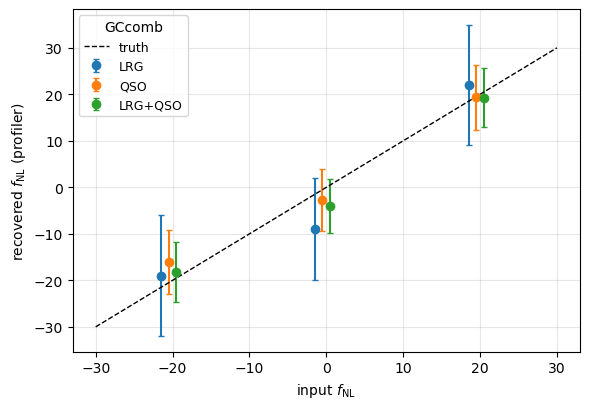

combination                           fnlm20            fnl0           fnl20
LRG                           -19.0 +/- 13.0   -9.0 +/- 11.0  +22.0 +/- 13.0
QSO                           -16.0 +/-  6.9   -2.7 +/-  6.7  +19.4 +/-  7.0
LRG+QSO                       -18.2 +/-  6.4   -4.1 +/-  5.8  +19.3 +/-  6.3
truth: fnlm20=-20, fnl0=+0, fnl20=+20


In [7]:
def fnl_bestfit(prof):
    s = prof.profiles.to_stats(tablefmt='list')[0][0]   # fnl_loc row: [name, varied, bestfit, error]
    return float(s[-2]), float(s[-1])

tags = ['-'.join(o) for o in ORDERS]
x = np.array([fnl_truth[f] for f in fnls])

plt.figure(figsize=(6, 4.2))
for i, tag in enumerate(tags[:-1]):
    bf = np.array([fnl_bestfit(profilers[(tag, f)]) for f in fnls])
    plt.errorbar(x + (i - 1.5) * 1.0, bf[:, 0], yerr=bf[:, 1], marker='o', ls='',
                 capsize=2, label=labels.get(tag, tag))
plt.plot([-30, 30], [-30, 30], 'k--', lw=1, label='truth')
plt.xlabel(r'input $f_{\rm NL}$'); plt.ylabel(r'recovered $f_{\rm NL}$ (profiler)')
plt.legend(title=region, fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# compact summary table
print(f'{"combination":28s}' + ''.join(f'{f:>16s}' for f in fnls))
for tag in tags[:-1]:
    row = [f'{fnl_bestfit(profilers[(tag, f)])[0]:+6.1f} +/- {fnl_bestfit(profilers[(tag, f)])[1]:4.1f}' for f in fnls]
    print(f'{labels.get(tag, tag):28s}' + ''.join(f'{c:>16s}' for c in row))
print('truth: ' + ', '.join(f'{f}={fnl_truth[f]:+.0f}' for f in fnls))

## (4) MCMC posteriors

Runs (or reloads) one chain per (combination, fNL), then plots the posteriors of the free
parameters for each combination overlaying the three fNL values. Set `FORCE=True` to
re-sample. Chains are slow; saved under `$SCRATCH/chains/pngunit-xl`.

In [9]:
RUN_MCMC = True
FORCE    = False
dir_chains = Path(os.environ['SCRATCH']) / 'chains' / 'pngunit-xl'
dir_chains.mkdir(parents=True, exist_ok=True)

chains = {}
if RUN_MCMC:
    import glob
    from desilike.samples import Chain
    for fnl in fnls:
        for order in ORDERS:
            tag = '-'.join(order)
            fn = str(dir_chains / f'chains_{tag}_{fnl}_*.npy')
            if FORCE or not Path(fn.replace('*', '0')).exists():
                _, lik = fit_combo(order, fnl)
                chains[(tag, fnl)] = run_mcmc(lik, fn_output=fn,
                                              max_iterations=20000, check_every=10000).chains
            else:
                chains[(tag, fnl)] = [Chain.load(f) for f in sorted(glob.glob(fn))]
            logger.info(f'chain ready: {tag} {fnl}')

[000380.46] [0/1] 06-10 13:48  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000380.57] [0/1] 06-10 13:48  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[000380.68] [0/1] 06-10 13:48  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000381.62] [0/1] 06-10 13:48  ObservablesGaussianLikelihood INFO     Covariance matrix with 37 points built from 1000 observations.
[000381.63] [0/1] 06-10 13:48  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9620.
[000388.32] [0/1] 06-10 13:48  ObservablesGaussianLikelihood INFO     Covariance matrix with 37 points built from 1000 observations, varying 4 parameters.
[000388.32] [0/1] 06-10 13:48  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0290.
[000388.36] [0/1] 06-10 13:48  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0

100%|██████████| 10000/10000 [01:20<00:00, 123.99it/s]


[000471.45] [0/1] 06-10 13:50  Chain                     INFO     Saving /pscratch/sd/n/nsailer/chains/pngunit-xl/chains_LRGxLRG_fnlm20_0.npy.


100%|██████████| 10000/10000 [01:18<00:00, 127.80it/s]


[000549.82] [0/1] 06-10 13:51  Chain                     INFO     Saving /pscratch/sd/n/nsailer/chains/pngunit-xl/chains_LRGxLRG_fnlm20_0.npy.
[000549.86] [0/1] 06-10 13:51  FIT PNG-UNIT-XL           INFO     chain ready: LRGxLRG fnlm20
[000549.99] [0/1] 06-10 13:51  PNG fitting tools         INFO     tracers_theo=['QSO_ell0'], ell=0, zeff=2.125
[000550.11] [0/1] 06-10 13:51  PNG fitting tools         INFO     tracers_theo=['QSO_ell2'], ell=2, zeff=2.004
[000550.22] [0/1] 06-10 13:51  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000551.20] [0/1] 06-10 13:51  ObservablesGaussianLikelihood INFO     Covariance matrix with 39 points built from 1000 observations.
[000551.20] [0/1] 06-10 13:51  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9600.
[000557.94] [0/1] 06-10 13:51  ObservablesGaussianLikelihood INFO     Covariance matrix with 39 points built from 1000 observations, varying 4 parameters.
[000557.94] [0/1] 06-

...

[003096.00] [0/1] 06-10 14:33  Chain                     INFO     Saving /pscratch/sd/n/nsailer/chains/pngunit-xl/chains_LRGxLRG-QSOxQSO_fnl20_0.npy.
[003096.09] [0/1] 06-10 14:33  FIT PNG-UNIT-XL           INFO     chain ready: LRGxLRG-QSOxQSO fnl20
[003096.21] [0/1] 06-10 14:33  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[003096.33] [0/1] 06-10 14:33  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[003096.44] [0/1] 06-10 14:33  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[003097.37] [0/1] 06-10 14:33  ObservablesGaussianLikelihood INFO     Covariance matrix with 37 points built from 1000 observations.
[003097.38] [0/1] 06-10 14:33  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9620.
[003104.10] [0/1] 06-10 14:34  ObservablesGaussianLikelihood INFO     Covariance matrix with 37 points built from 1000 observations, varying 4 parameters.
[00310

100%|██████████| 10000/10000 [03:22<00:00, 49.40it/s]


[003328.58] [0/1] 06-10 14:37  Chain                     INFO     Saving /pscratch/sd/n/nsailer/chains/pngunit-xl/chains_LRGxLRG-QSOxQSO-LRGxQSO_fnl20_0.npy.


100%|██████████| 10000/10000 [03:12<00:00, 51.89it/s]


[003521.70] [0/1] 06-10 14:41  Chain                     INFO     Saving /pscratch/sd/n/nsailer/chains/pngunit-xl/chains_LRGxLRG-QSOxQSO-LRGxQSO_fnl20_0.npy.
[003521.90] [0/1] 06-10 14:41  FIT PNG-UNIT-XL           INFO     chain ready: LRGxLRG-QSOxQSO-LRGxQSO fnl20


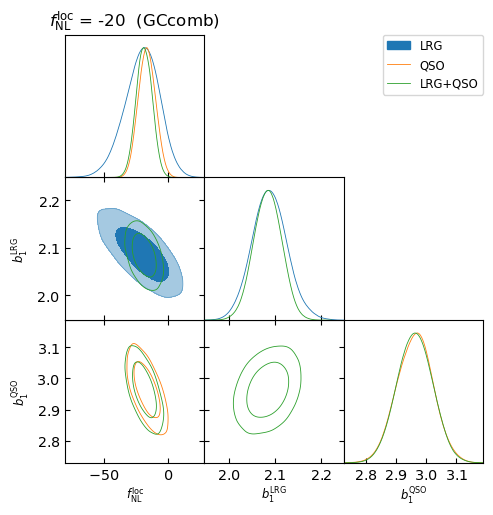

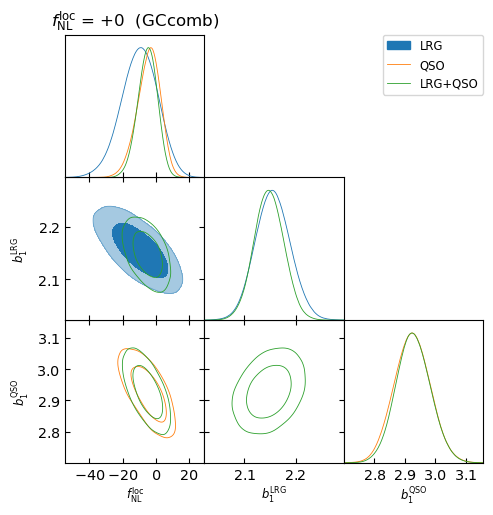

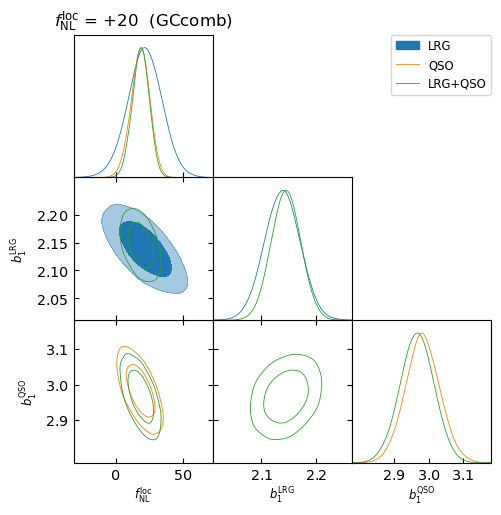

In [10]:
if RUN_MCMC:
    from desilike.samples import Chain
    burnin, thin = 0.3, 10

    # tracer combos to overlay, skipping anything with LRGxQSO
    combo_orders = [o for o in ORDERS if 'LRGxQSO' not in o]
    params = ['fnl_loc', 'LRG_ell0.b1', 'QSO_ell0.b1']   # union across combos
    xl = {'fnl_loc': r'$f_{\rm NL}^{\rm loc}$',
          'LRG_ell0.b1': r'$b_1^{\rm LRG}$',
          'QSO_ell0.b1': r'$b_1^{\rm QSO}$'}
    combo_color = {'LRGxLRG': 'C0', 'QSOxQSO': 'C1', 'LRGxLRG-QSOxQSO': 'C2'}

    for f in fnls:
        disp = [Chain.concatenate([c.remove_burnin(burnin)[::thin]
                                   for c in chains[('-'.join(o), f)]])
                for o in combo_orders]
        tags = ['-'.join(o) for o in combo_orders]
        g = get_getdist_plotter(fig_width_inch=5)
        fig = plot_triangle(disp, params,
                            legend_labels=[labels.get(t, t) for t in tags],
                            xlabels=[xl[p] for p in params],
                            contour_colors=[combo_color[t] for t in tags],
                            #markers={'fnl_loc': fnl_truth[f]},   # truth line
                            g=g, return_fig=True)
        fig.get_axes()[len(params) - 1].set_title(
            f'{xl["fnl_loc"]} = {fnl_truth[f]:+.0f}  ({region})')
        plt.show()

In [11]:
if RUN_MCMC:
    from desilike.samples import Chain
    print(f'{"combination":28s}' + ''.join(f'{f:>18s}' for f in fnls))
    for order in ORDERS:
        tag = '-'.join(order); row = []
        for f in fnls:
            cc = Chain.concatenate([c.remove_burnin(0.3)[::10] for c in chains[(tag, f)]])
            st = cc.to_stats(params=['fnl_loc'], quantities=['mean', 'interval:1sigma'], tablefmt='list')[0][0]
            row.append(f'{float(st[1]):+.1f} ({st[2]})')
        print(f'{labels.get(tag, tag):28s}' + ''.join(f'{c:>18s}' for c in row))
    print('truth: ' + ', '.join(f'{f}={fnl_truth[f]:+.0f}' for f in fnls))

combination                             fnlm20              fnl0             fnl20
LRG                            -20.0 (-12/+15)  -10.0 (-10./+12)   +22.0 (-13/+13)
QSO                          -16.4 (-6.8/+6.8)  -4.4 (-6.6/+7.3) +18.4 (-6.8/+7.1)
LRG+QSO                      -18.6 (-6.1/+6.3)  -5.1 (-5.6/+6.3) +18.8 (-5.6/+7.0)
LRGxQSO                      -20.2 (-6.4/+5.1) +18.6 (-4.6/+5.4) +60.4 (-5.4/+6.0)
truth: fnlm20=-20, fnl0=+0, fnl20=+20
